In [1]:
import pandas as pd

bins = pd.read_csv("Bins.csv")
trucks = pd.read_csv("Trucks.csv")
routes = pd.read_csv("Routes.csv")

In [2]:
print(bins.columns)
print(trucks.columns)
print(routes.columns)

Index(['BinID', 'Ward', 'AreaType', 'PopulationDensity', 'WasteType',
       'Capacity_Ltrs', 'Latitude', 'Longitude'],
      dtype='object')
Index(['TruckID', 'Model', 'FuelType', 'Specialization', 'FuelPerKm'], dtype='object')
Index(['RouteID', 'BinID', 'TruckID', 'Sequence', 'Distance_KM'], dtype='object')


In [3]:
bins['PopulationDensity_Score'] = bins['PopulationDensity'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

In [4]:
bins['Priority'] = (
    bins['PopulationDensity_Score'] * 0.7 +
    (1000 / bins['Capacity_Ltrs']) * 0.3
)

In [5]:
print(bins[['BinID', 'PopulationDensity', 'PopulationDensity_Score', 'Capacity_Ltrs', 'Priority']].head())

   BinID PopulationDensity  PopulationDensity_Score  Capacity_Ltrs  Priority
0  B1000              High                        3            500     2.700
1  B1001              High                        3           1000     2.400
2  B1002              High                        3            800     2.475
3  B1003              High                        3            300     3.100
4  B1004            Medium                        2            300     2.400


In [6]:
important_bins = bins[bins['Priority'] > bins['Priority'].mean()]

print(important_bins[['BinID', 'Priority']])

    BinID  Priority
0   B1000     2.700
2   B1002     2.475
3   B1003     3.100
10  B1010     2.700
11  B1011     2.700
13  B1013     2.700
14  B1014     2.900
15  B1015     2.700
18  B1018     2.475
19  B1019     2.700
21  B1021     2.700
22  B1022     3.100
26  B1026     2.900
27  B1027     2.900
29  B1029     2.700
31  B1031     2.700
33  B1033     2.475
36  B1036     2.700
40  B1040     2.700
49  B1049     2.475
51  B1051     2.700
52  B1052     2.900
55  B1055     2.475
56  B1056     2.475
57  B1057     3.100
58  B1058     3.100
61  B1061     2.900
67  B1067     2.475
69  B1069     2.700
71  B1071     2.700
72  B1072     2.475
73  B1073     2.700
74  B1074     2.475
76  B1076     2.700
77  B1077     2.900
80  B1080     2.900
83  B1083     2.700
85  B1085     2.700
86  B1086     2.900
89  B1089     2.700


In [7]:
important_bins = important_bins.reset_index(drop=True)

In [8]:
from math import radians, sin, cos, sqrt, atan2

def distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Earth radius in km

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

In [9]:
distance_matrix = []

for i in range(len(important_bins)):
    row = []
    
    for j in range(len(important_bins)):
        dist = distance(
            important_bins.iloc[i]['Latitude'],
            important_bins.iloc[i]['Longitude'],
            important_bins.iloc[j]['Latitude'],
            important_bins.iloc[j]['Longitude']
        )
        row.append(dist)
    
    distance_matrix.append(row)

In [10]:
print(len(distance_matrix))
print(distance_matrix[0][:5])

40
[0.0, 5.762398622267937, 2.8972386951974993, 10.11517865915099, 8.763392240517781]


In [11]:
num_trucks = len(trucks)

important_bins = important_bins.copy()

important_bins['Truck_Assigned'] = [
    i % num_trucks for i in range(len(important_bins))
]

print(important_bins[['BinID', 'Truck_Assigned']].head(10))

   BinID  Truck_Assigned
0  B1000               0
1  B1002               1
2  B1003               2
3  B1010               3
4  B1011               4
5  B1013               5
6  B1014               6
7  B1015               7
8  B1018               8
9  B1019               9


In [12]:
def simple_route(indices, matrix):
    route = [indices[0]]
    visited = set(route)

    while len(route) < len(indices):
        last = route[-1]

        next_bin = min(
            [i for i in indices if i not in visited],
            key=lambda x: matrix[last][x]
        )

        route.append(next_bin)
        visited.add(next_bin)

    return route

In [13]:
num_trucks = 5  # keep it realistic (try 4–6 trucks)

important_bins = important_bins.copy()

important_bins['Truck_Assigned'] = [
    i % num_trucks for i in range(len(important_bins))
]

print(important_bins[['BinID', 'Truck_Assigned']].head(15))

    BinID  Truck_Assigned
0   B1000               0
1   B1002               1
2   B1003               2
3   B1010               3
4   B1011               4
5   B1013               0
6   B1014               1
7   B1015               2
8   B1018               3
9   B1019               4
10  B1021               0
11  B1022               1
12  B1026               2
13  B1027               3
14  B1029               4


In [14]:
all_routes = {}

for truck in range(num_trucks):
    
    # get bin indices for this truck
    bin_indices = important_bins[
        important_bins['Truck_Assigned'] == truck
    ].index.tolist()
    
    if len(bin_indices) > 1:
        route = simple_route(bin_indices, distance_matrix)
    else:
        route = bin_indices
    
    all_routes[truck] = route

In [15]:
all_routes = {}

for truck in range(num_trucks):
    
    # get bin indices for this truck
    bin_indices = important_bins[
        important_bins['Truck_Assigned'] == truck
    ].index.tolist()
    
    if len(bin_indices) > 1:
        route = simple_route(bin_indices, distance_matrix)
    else:
        route = bin_indices
    
    all_routes[truck] = route

In [16]:
for truck, route in all_routes.items():
    print(f"Truck {truck} route:", route)

Truck 0 route: [0, 30, 35, 5, 20, 25, 10, 15]
Truck 1 route: [1, 11, 36, 16, 31, 26, 6, 21]
Truck 2 route: [2, 37, 27, 32, 22, 17, 12, 7]
Truck 3 route: [3, 38, 18, 8, 33, 28, 13, 23]
Truck 4 route: [4, 14, 39, 34, 19, 29, 24, 9]


In [17]:
for truck, route in all_routes.items():
    
    bin_ids = [important_bins.iloc[i]['BinID'] for i in route]
    
    print(f"Truck {truck} route:", bin_ids)

Truck 0 route: ['B1000', 'B1072', 'B1080', 'B1013', 'B1051', 'B1058', 'B1021', 'B1031']
Truck 1 route: ['B1002', 'B1022', 'B1083', 'B1033', 'B1073', 'B1061', 'B1014', 'B1052']
Truck 2 route: ['B1003', 'B1085', 'B1067', 'B1074', 'B1055', 'B1036', 'B1026', 'B1015']
Truck 3 route: ['B1010', 'B1086', 'B1040', 'B1018', 'B1076', 'B1069', 'B1027', 'B1056']
Truck 4 route: ['B1011', 'B1029', 'B1089', 'B1077', 'B1049', 'B1071', 'B1057', 'B1019']


In [18]:
#Machine Learing model

In [19]:
ml_data = bins.copy()

# Convert AreaType to numbers
ml_data['AreaType_Code'] = ml_data['AreaType'].map({
    'Residential': 1,
    'Commercial': 2,
    'Industrial': 3,
    'Hospital': 4,
    'Market': 5
})

# Convert WasteType to numbers
ml_data['WasteType_Code'] = ml_data['WasteType'].map({
    'General': 1,
    'Organic': 2,
    'Recyclable': 3
})

In [20]:
ml_data['Target'] = (ml_data['Priority'] > ml_data['Priority'].mean()).astype(int)

In [21]:
X = ml_data[['PopulationDensity_Score', 'Capacity_Ltrs', 'AreaType_Code', 'WasteType_Code']]
y = ml_data['Target']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [24]:
import numpy as np

ml_data['Target'] = (
    (ml_data['Priority'] > ml_data['Priority'].mean()) &
    (np.random.rand(len(ml_data)) > 0.2)
).astype(int)

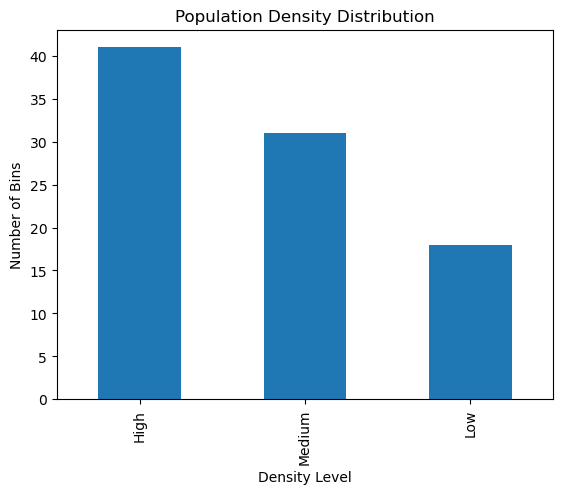

In [25]:
import matplotlib.pyplot as plt

# Count of Population Density
bins['PopulationDensity'].value_counts().plot(kind='bar')
plt.title("Population Density Distribution")
plt.xlabel("Density Level")
plt.ylabel("Number of Bins")
plt.show()

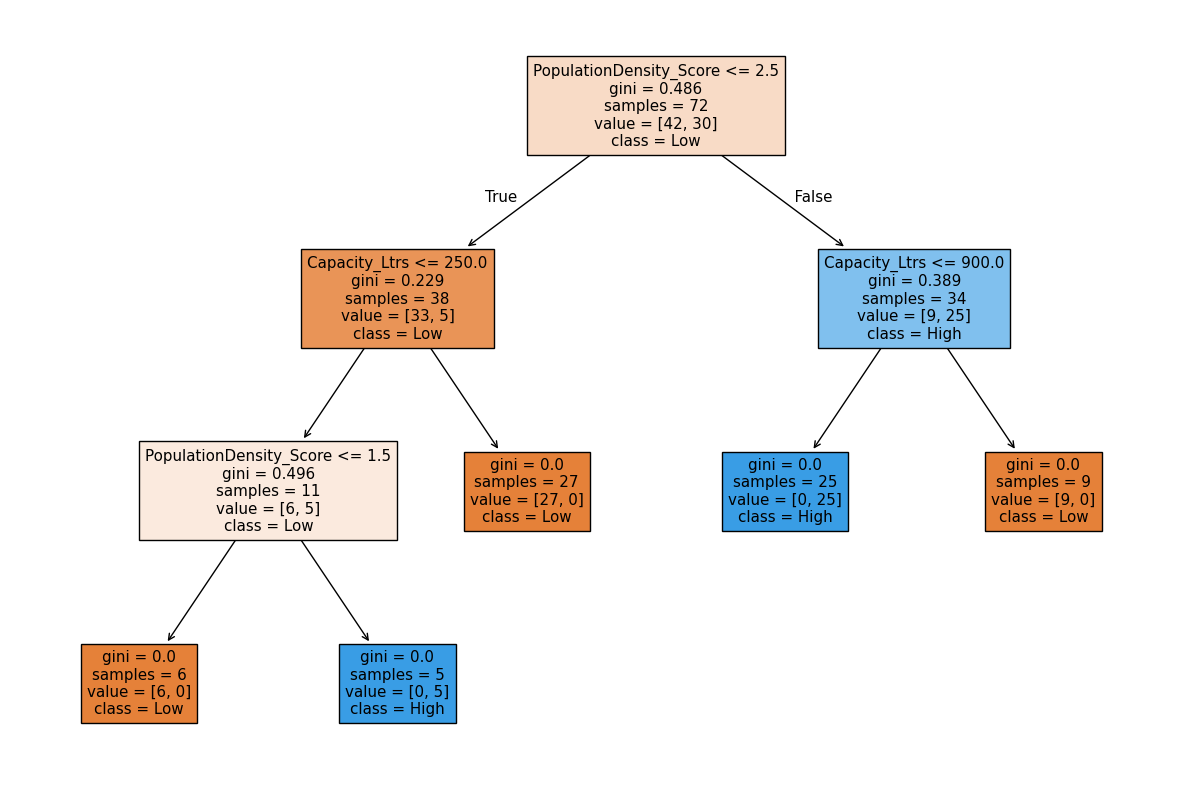

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))

plot_tree(model, feature_names=X.columns, class_names=['Low','High'], filled=True)

plt.show()

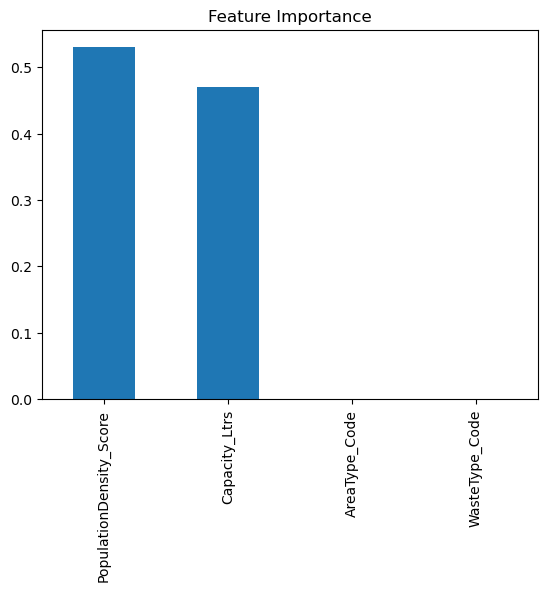

In [27]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.plot(kind='bar')

plt.title("Feature Importance")
plt.show()

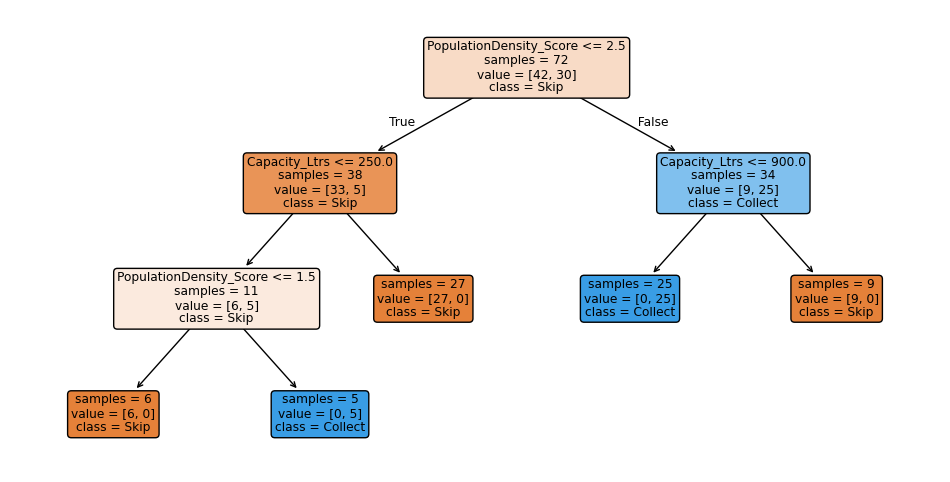

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Skip', 'Collect'],
    filled=True,
    impurity=False,   # removes gini
    proportion=False,
    rounded=True
)

plt.show()

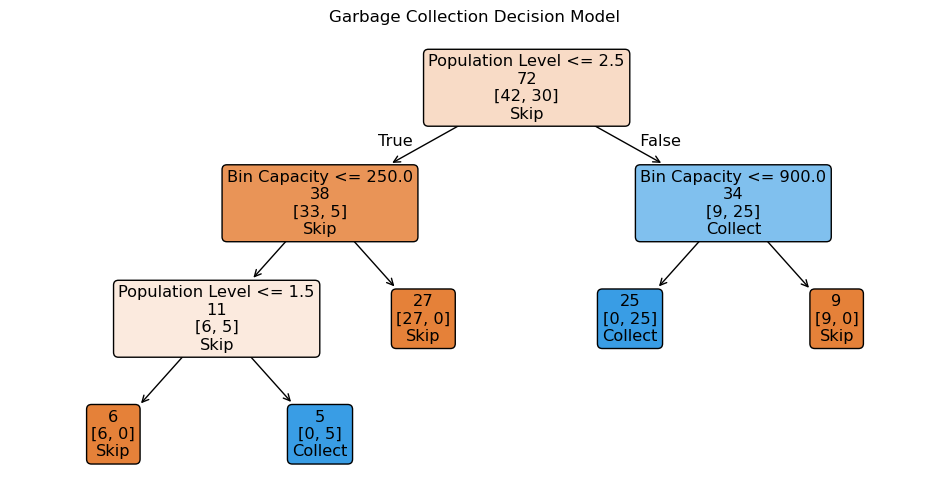

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))

plot_tree(
    model,
    feature_names=[
        'Population Level',
        'Bin Capacity',
        'Area Type',
        'Waste Type'
    ],
    class_names=['Skip', 'Collect'],
    filled=True,
    impurity=False,   # removes gini
    label='none',     # removes extra text
    rounded=True
)

plt.title("Garbage Collection Decision Model")

plt.show()